In [1]:
pip install --upgrade yfinance

In [2]:
import pandas_datareader as web
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
# Read S&P 500 list from Wikipedia
sp = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', header=0)[0]

In [5]:
print(sp.columns)

Index(['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry',
       'Headquarters Location', 'Date added', 'CIK', 'Founded'],
      dtype='object')


In [6]:
hce_tickers = sp[sp['GICS Sub-Industry'] == 'Health Care Equipment']['Symbol'].tolist()

In [7]:
start_date = '2010-01-01'
end_date = '2025-02-20'
data = yf.download(hce_tickers, start=start_date, end=end_date)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  18 of 18 completed


In [63]:


# Read S&P 500 list from Wikipedia
sp = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', header=0)[0]

# Filter for Health Care Equipment companies
hce_tickers = sp[sp['GICS Sub-Industry'] == 'Health Care Equipment']['Symbol'].tolist()

# Print the first 18 tickers
print(hce_tickers[:18])


['ABT', 'BAX', 'BDX', 'BSX', 'DXCM', 'EW', 'GEHC', 'HOLX', 'IDXX', 'PODD', 'ISRG', 'MDT', 'RMD', 'RVTY', 'STE', 'SYK', 'TFX', 'ZBH']


In [9]:
close_prices = data['Close']

In [12]:
monthly_prices = close_prices.resample('M').last()  # Resample to monthly
monthly_returns = monthly_prices.pct_change()  # Calculate monthly returns

<ipython-input-12-762e330952d9>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = close_prices.resample('M').last()  # Resample to monthly


In [13]:
sp500_data = yf.download('^GSPC', start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [16]:
sp500_monthly_prices = sp500_data['Close'].resample('M').last()
sp500_monthly_returns = sp500_monthly_prices.pct_change()



<ipython-input-16-ba5203e2c07e>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sp500_monthly_prices = sp500_data['Close'].resample('M').last()


In [19]:
sp500_monthly_returns = sp500_monthly_returns.rename(columns={'^GSPC': 'SP500_Returns'})

In [20]:
merged_data = pd.merge(monthly_returns, sp500_monthly_returns, left_index=True, right_index=True)


In [21]:
print(merged_data.head())

Ticker           ABT       BAX       BDX       BSX      DXCM        EW  GEHC  \
Date                                                                           
2010-01-31       NaN       NaN       NaN       NaN       NaN       NaN   NaN   
2010-02-28  0.025311 -0.011460  0.033170 -0.103129 -0.002208  0.024660   NaN   
2010-03-31 -0.029476  0.027317  0.015826 -0.067183  0.077434  0.076772   NaN   
2010-04-30 -0.020673 -0.188660 -0.029976 -0.047091  0.124230  0.042476   NaN   
2010-05-31 -0.070368 -0.105676 -0.066387 -0.120640 -0.038356 -0.019596   NaN   

Ticker          HOLX      IDXX      ISRG       MDT      PODD       RMD  \
Date                                                                     
2010-01-31       NaN       NaN       NaN       NaN       NaN       NaN   
2010-02-28  0.144658  0.005906  0.058160  0.011891  0.078503  0.116152   
2010-03-31  0.074783  0.089962  0.002852  0.037557  0.026531  0.115102   
2010-04-30 -0.035599  0.149262  0.035705 -0.025361 -0.084824  0.07509

In [22]:
start_date = '1950-01-01'
end_date = '2025-02-20'
tb3ms_data = web.DataReader('TB3MS', 'fred', start_date, end_date)


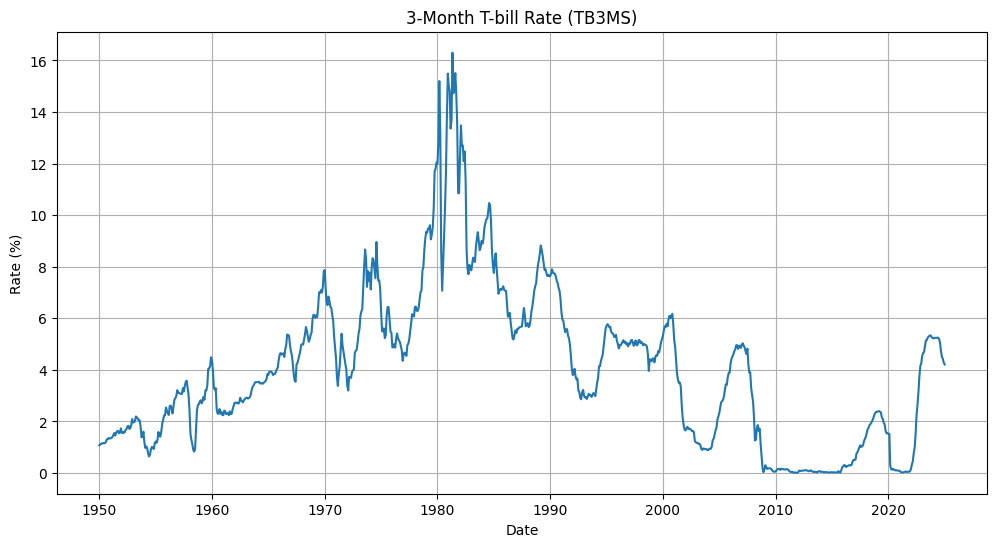

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(tb3ms_data)
plt.title('3-Month T-bill Rate (TB3MS)')
plt.xlabel('Date')
plt.ylabel('Rate (%)')
plt.grid(True)
plt.show()

In [24]:
tb3ms_monthly = tb3ms_data.resample('M').last()

<ipython-input-24-74caad7382b5>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  tb3ms_monthly = tb3ms_data.resample('M').last()


In [25]:

# Merge with stock and index returns
merged_data = pd.merge(merged_data, tb3ms_monthly, left_index=True, right_index=True, how='left')


In [26]:
print(merged_data.head())

                 ABT       BAX       BDX       BSX      DXCM        EW  GEHC  \
Date                                                                           
2010-01-31       NaN       NaN       NaN       NaN       NaN       NaN   NaN   
2010-02-28  0.025311 -0.011460  0.033170 -0.103129 -0.002208  0.024660   NaN   
2010-03-31 -0.029476  0.027317  0.015826 -0.067183  0.077434  0.076772   NaN   
2010-04-30 -0.020673 -0.188660 -0.029976 -0.047091  0.124230  0.042476   NaN   
2010-05-31 -0.070368 -0.105676 -0.066387 -0.120640 -0.038356 -0.019596   NaN   

                HOLX      IDXX      ISRG       MDT      PODD       RMD  \
Date                                                                     
2010-01-31       NaN       NaN       NaN       NaN       NaN       NaN   
2010-02-28  0.144658  0.005906  0.058160  0.011891  0.078503  0.116152   
2010-03-31  0.074783  0.089962  0.002852  0.037557  0.026531  0.115102   
2010-04-30 -0.035599  0.149262  0.035705 -0.025361 -0.084824  0.07509

In [27]:

# Calculate excess returns
merged_data['SP500_Excess_Returns'] = merged_data['SP500_Returns'] - merged_data['TB3MS'] / 1200  # Adjust T-bill rate to monthly
for ticker in hce_tickers:
    if ticker in merged_data.columns:  # Check if ticker exists in the DataFrame
        merged_data[ticker + '_Excess_Returns'] = merged_data[ticker] - merged_data['TB3MS'] / 1200

In [28]:
# Calculate annual Sharpe ratio for each company
annualized_sharpe_ratios = {}
for ticker in hce_tickers:
    if ticker + '_Excess_Returns' in merged_data.columns:  # Check if excess returns column exists
        excess_returns = merged_data[ticker + '_Excess_Returns'].dropna()
        annualized_sharpe_ratios[ticker] = (excess_returns.mean() / excess_returns.std()) * np.sqrt(12)  # Annualize

In [29]:

# Calculate average annual Sharpe ratio for each company
average_sharpe_ratios = {ticker: sharpe_ratios.mean() for ticker, sharpe_ratios in annualized_sharpe_ratios.items()}


In [30]:

# Print the average annual Sharpe ratios
print("Average Annual Sharpe Ratios:")
for ticker, sharpe_ratio in average_sharpe_ratios.items():
    print(f"{ticker}: {sharpe_ratio:.4f}")

Average Annual Sharpe Ratios:
ABT: 0.7191
BAX: 0.1596
BDX: 0.5626
BSX: 0.7413
DXCM: 0.7220
EW: 0.6080
GEHC: 0.6199
HOLX: 0.4706
IDXX: 0.7563
PODD: 0.6881
ISRG: 0.7385
MDT: 0.4094
RMD: 0.7042
RVTY: 0.5703
STE: 0.7634
SYK: 0.7616
TFX: 0.4223
ZBH: 0.2939


In [31]:
# Select top 5 stocks with largest Sharpe ratios
top_5_stocks = pd.Series(average_sharpe_ratios).nlargest(5)

In [32]:
top_5_table = pd.DataFrame({'Ticker': top_5_stocks.index, 'Sharpe Ratio': top_5_stocks.values})
print(top_5_table)


  Ticker  Sharpe Ratio
0    STE      0.763420
1    SYK      0.761583
2   IDXX      0.756294
3    BSX      0.741271
4   ISRG      0.738504


In [34]:
# Optimal portfolio (tickers of the top 5 stocks)
optimal_portfolio = top_5_stocks.index.tolist()
print("\nOptimal Portfolio:", optimal_portfolio)


Optimal Portfolio: ['STE', 'SYK', 'IDXX', 'BSX', 'ISRG']


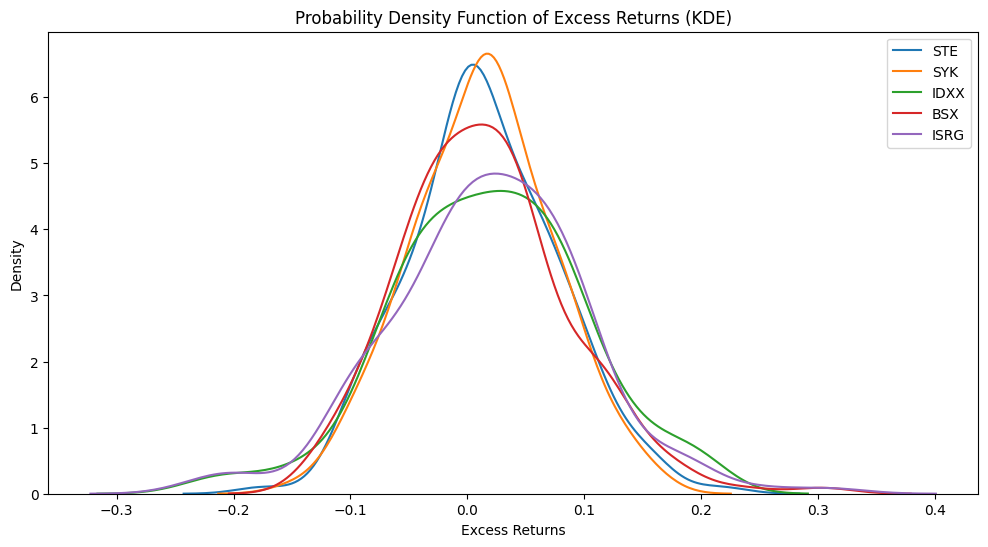

In [35]:
# Create KDE plot of excess returns for top 5 stocks
plt.figure(figsize=(12, 6))
for ticker in optimal_portfolio:
    sns.kdeplot(merged_data[ticker + '_Excess_Returns'].dropna(), label=ticker)
plt.title('Probability Density Function of Excess Returns (KDE)')
plt.xlabel('Excess Returns')
plt.ylabel('Density')
plt.legend()
plt.show()

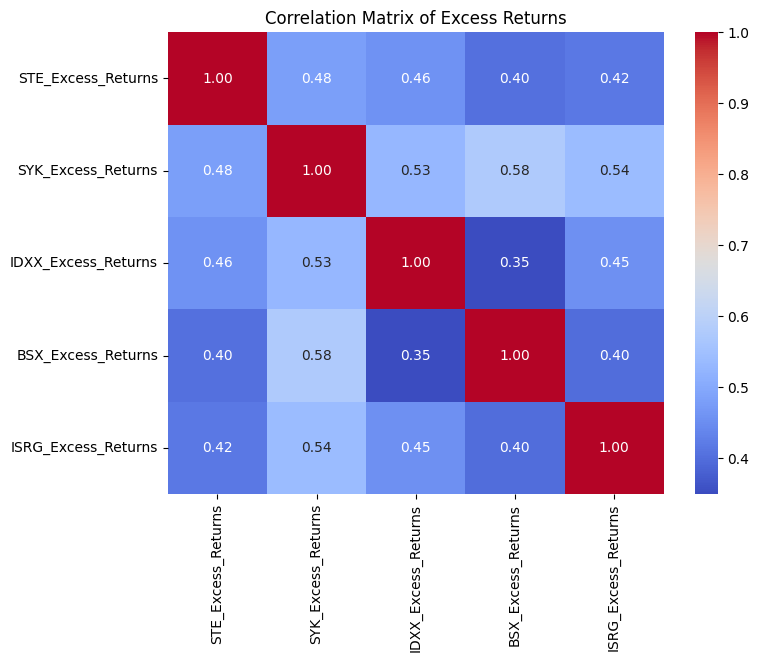

In [36]:
top_5_returns = merged_data[[ticker + '_Excess_Returns' for ticker in optimal_portfolio]].dropna()
correlation_matrix = top_5_returns.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Excess Returns')
plt.show()

In [43]:
#Running Framm French Factor Model
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='2012')[0].drop(['RMW','CMA'], axis=1)

<ipython-input-43-08285fce934d>:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='2012')[0].drop(['RMW','CMA'], axis=1)
<ipython-input-43-08285fce934d>:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='2012')[0].drop(['RMW','CMA'], axis=1)


In [44]:
factor_data

,Mkt-RF,SMB,HML,RF
Date,,,,
2012-01,5.05,2.06,-0.97,0.00
2012-02,4.42,-1.71,0.43,0.00
2012-03,3.11,-0.47,1.14,0.00
2012-04,-0.85,-0.55,-0.78,0.00
2012-05,-6.19,-0.12,-1.07,0.01
...,...,...,...,...
2024-08,1.61,-3.65,-1.13,0.48
2024-09,1.74,-1.02,-2.59,0.40
2024-10,-0.97,-0.88,0.89,0.39


In [45]:
factor_data.index = factor_data.index.format()

factor_data = factor_data.div(100)

<ipython-input-45-d6e7d6070e5b>:1: FutureWarning: PeriodIndex.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  factor_data.index = factor_data.index.format()


In [46]:
factor_data

,Mkt-RF,SMB,HML,RF
2012-01,0.0505,0.0206,-0.0097,0.0000
2012-02,0.0442,-0.0171,0.0043,0.0000
2012-03,0.0311,-0.0047,0.0114,0.0000
2012-04,-0.0085,-0.0055,-0.0078,0.0000
2012-05,-0.0619,-0.0012,-0.0107,0.0001
...,...,...,...,...
2024-08,0.0161,-0.0365,-0.0113,0.0048
2024-09,0.0174,-0.0102,-0.0259,0.0040
2024-10,-0.0097,-0.0088,0.0089,0.0039
2024-11,0.0651,0.0478,-0.0005,0.0040


In [50]:
ret = top_5_returns.copy()

In [51]:
ret.index = ret.index.strftime('%Y-%m')

In [52]:
ret

,STE_Excess_Returns,SYK_Excess_Returns,IDXX_Excess_Returns,BSX_Excess_Returns,ISRG_Excess_Returns
Date,,,,,
2010-02,0.216208,0.022635,0.005814,-0.103220,0.058068
2010-03,0.064728,0.080274,0.089837,-0.067308,0.002727
2010-04,-0.011423,0.003711,0.149128,-0.047225,0.035572
2010-05,-0.040389,-0.076909,-0.043980,-0.120773,-0.104942
2010-06,-0.023663,-0.053271,-0.037102,-0.041422,-0.022252
...,...,...,...,...,...
2024-09,0.004430,0.000628,0.045700,0.020642,-0.006694
2024-10,-0.089064,-0.017543,-0.198327,-0.001133,0.021828
2024-11,-0.013660,0.096996,0.032761,0.075346,0.072055


In [53]:
#Add risk free rate and calculate excess rate
excess_ret = pd.merge(ret,factor_data['RF'],
                       left_index=True,
                       right_index=True,
                       how = 'inner')

excess_ret = excess_ret.sub(excess_ret['RF'], axis=0).drop(columns=['RF'])

In [54]:
#Merge excess rate with factor data
ret_factor = pd.merge(factor_data, excess_ret,
                      left_index=True,
                      right_index=True,
                      how='inner')

In [55]:
ret_factor

,Mkt-RF,SMB,HML,RF,STE_Excess_Returns,SYK_Excess_Returns,IDXX_Excess_Returns,BSX_Excess_Returns,ISRG_Excess_Returns
2012-01,0.0505,0.0206,-0.0097,0.0000,0.008694,0.115043,0.099117,0.116080,-0.006720
2012-02,0.0442,-0.0171,0.0043,0.0000,0.048668,-0.032368,0.013638,0.043549,0.112360
2012-03,0.0311,-0.0047,0.0114,0.0000,0.007581,0.038232,0.019758,-0.038652,0.058825
2012-04,-0.0085,-0.0055,-0.0078,0.0000,-0.006708,-0.016469,0.005422,0.046756,0.067215
2012-05,-0.0619,-0.0012,-0.0107,0.0001,-0.049522,-0.057349,-0.035317,-0.083242,-0.095471
...,...,...,...,...,...,...,...,...,...
2024-08,0.0161,-0.0365,-0.0113,0.0048,0.000792,0.091679,0.001934,0.098057,0.098996
2024-09,0.0174,-0.0102,-0.0259,0.0040,0.000430,-0.003372,0.041700,0.016642,-0.010694
2024-10,-0.0097,-0.0088,0.0089,0.0039,-0.092964,-0.021443,-0.202227,-0.005033,0.017928
2024-11,0.0651,0.0478,-0.0005,0.0040,-0.017660,0.092996,0.028761,0.071346,0.068055


In [62]:
# prompt: run Fama-French three factor regression for each of the 5 stocks

# Loop through each stock in the optimal portfolio
for ticker in optimal_portfolio:
    # Prepare the data for regression
    y = ret_factor[ticker + '_Excess_Returns']
    X = ret_factor[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)

    # Run the regression
    model = sm.OLS(y, X).fit()

    # Print the regression results
    print(f"\nFama-French Three-Factor Regression for {ticker}:")
    print(model.summary())



Fama-French Three-Factor Regression for STE:
                            OLS Regression Results                            
Dep. Variable:     STE_Excess_Returns   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     28.84
Date:                Thu, 27 Feb 2025   Prob (F-statistic):           8.06e-15
Time:                        19:08:23   Log-Likelihood:                 245.43
No. Observations:                 156   AIC:                            -482.9
Df Residuals:                     152   BIC:                            -470.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 